<a href="https://colab.research.google.com/github/siddhantsawhney327/6thSem-ML-Lab/blob/main/1BM23CS327_Lab_7_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Class labels:
['setosa' 'versicolor' 'virginica']

=== RANDOM FOREST WITH DEFAULT n_estimators=10 ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy

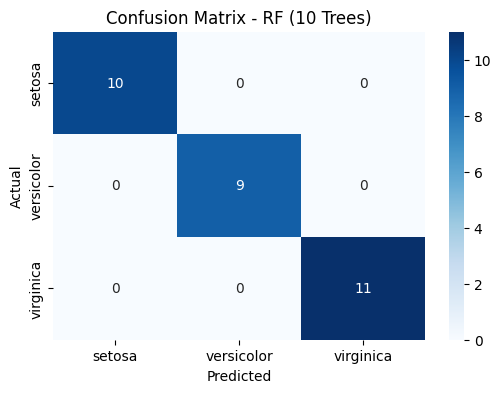


=== TUNING n_estimators ===
Number of Trees = 5, Accuracy = 0.9666666666666667
Number of Trees = 10, Accuracy = 1.0
Number of Trees = 20, Accuracy = 1.0
Number of Trees = 50, Accuracy = 1.0
Number of Trees = 100, Accuracy = 1.0
Number of Trees = 150, Accuracy = 1.0
Number of Trees = 200, Accuracy = 1.0

=== BEST MODEL ===
Best Accuracy Score: 1.0
Best Number of Trees: 10

Confusion Matrix for Best Model:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report for Best Model:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



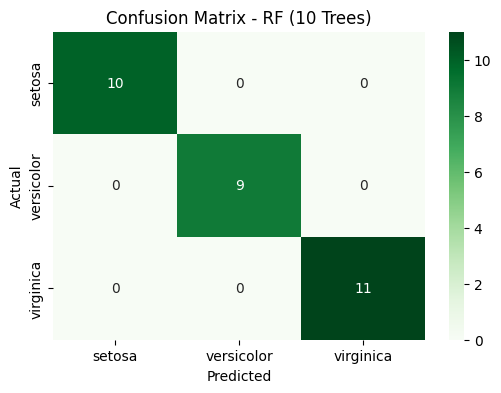

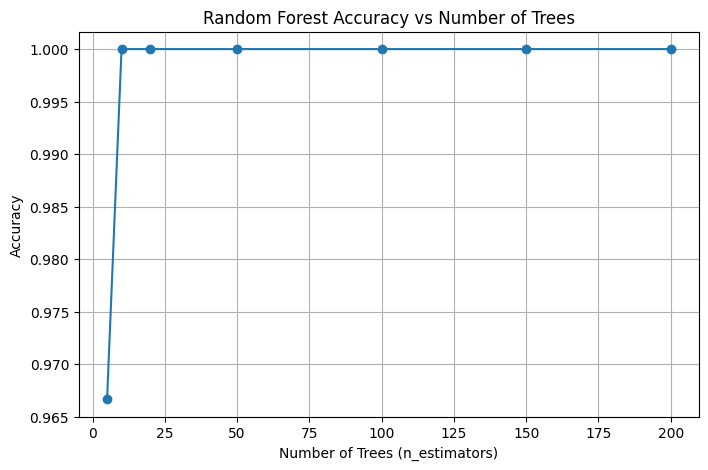

In [1]:
# ==========================================
# LAB-7: RANDOM FOREST CLASSIFIER - IRIS
# ==========================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load IRIS dataset
iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Optional: Convert to DataFrame for better understanding
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("First 5 rows of dataset:")
print(df.head())

print("\nClass labels:")
print(iris.target_names)

# Step 3: Split data into training and testing
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Build Random Forest model with default n_estimators = 10
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

# Step 5: Predict on test data
y_pred_default = rf_default.predict(X_test)

# Step 6: Evaluate default model
acc_default = accuracy_score(y_test, y_pred_default)
cm_default = confusion_matrix(y_test, y_pred_default)

print("\n=== RANDOM FOREST WITH DEFAULT n_estimators=10 ===")
print("Accuracy:", acc_default)
print("Confusion Matrix:\n", cm_default)
print("\nClassification Report:\n", classification_report(y_test, y_pred_default, target_names=iris.target_names))

# Plot confusion matrix for default model
plt.figure(figsize=(6,4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Confusion Matrix - RF (10 Trees)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 7: Fine-tuning by changing number of trees
tree_values = [5, 10, 20, 50, 100, 150, 200]
scores = []

print("\n=== TUNING n_estimators ===")
for n in tree_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Number of Trees = {n}, Accuracy = {acc}")

# Step 8: Find best score and best number of trees
best_score = max(scores)
best_trees = tree_values[scores.index(best_score)]

print("\n=== BEST MODEL ===")
print("Best Accuracy Score:", best_score)
print("Best Number of Trees:", best_trees)

# Step 9: Train final best model
best_rf = RandomForestClassifier(n_estimators=best_trees, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

best_cm = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix for Best Model:\n", best_cm)
print("\nClassification Report for Best Model:\n", classification_report(y_test, y_pred_best, target_names=iris.target_names))

# Plot best model confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title(f"Confusion Matrix - RF ({best_trees} Trees)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 10: Plot Accuracy vs Number of Trees
plt.figure(figsize=(8,5))
plt.plot(tree_values, scores, marker='o')
plt.title("Random Forest Accuracy vs Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()